#   E. coli Adenine nucleotide wavelet analysis (WIP)

##  Description

This notebook is for analyzing the Adenine nucleotide signal with wavelets, in particular the Haar wavelet.

##  Approach

Start with some visualizations

##  Possible TODOs
- Compare wavelet approximation and detail coefficients across full-genome, CDS, and non-CDS signals.
- Study energy distribution across scales and how it changes across signal type or genomic region.
- Build spatial plots of reconstructed detail coefficients across scales.
- Investigate entropy across scales and relative entropy or divergence between CDS and non-CDS profiles.
- Add windowed wavelet comparisons (A vs C, or GC vs C, for instance).
- Add error analysis/quantification.
- Analyze computational complexity and scaling efficiency of wavelet operation.


## Choose Analysis Scales

Let's start out with Haar detail levels 1 through 8 for the full-genome analysis. These correspond roughly to spatial scales from 2 base pairs (bp) through 256 bp.  We can increase this if we think there is anything interesting at courser scales.

For windowed analyses, we use detail levels 1 through 7 (up to 128 bp) and start out with 4096-bp windows.  We can also increase this number if we suspect that there is anything interesting at courser scales.

In [2]:
# Constants
FULL_LEVEL = 8
WINDOW_SIZE = 4096
WINDOW_STEP = 2048
WINDOW_LEVEL = 7
MOTHER_WAVELET = "haar"

In [3]:
import io
import math
from enum import Enum

import numpy as np
import pandas as pd
import pywt
from Bio import Entrez, SeqIO
import Bio

import matplotlib.pyplot as plt
%matplotlib inline

ACCESSION = "NC_000913.3"  # E. coli K-12 MG1655 complete genome
EMAIL = "daniel_mcgonigle1@student.uml.edu"  # NCBI asks for an email

Entrez.email = EMAIL


In [4]:
def fetch_genbank_record(accession: str) -> Bio.SeqRecord.SeqRecord:
    """
    Fetch a nucleotide sequence record from NCBI and parse it into a Biopython SeqRecord.

    Parameters
    ----------
    accession : str
        RefSeq or GenBank accession for the genome of interest.

    Returns
    -------
    Bio.SeqRecord.SeqRecord
        Parsed record containing the DNA sequence and feature annotations.
    """
    with Entrez.efetch(db="nuccore", id=accession, rettype="gbwithparts", retmode="text") as handle:
        text = handle.read()
    return SeqIO.read(io.StringIO(text), "genbank")


class SignalType(str, Enum):
    """Signal domain choices for genome-derived indicator signals."""

    FULL = "full"
    CDS = "cds"
    NONCDS = "noncds"


record = fetch_genbank_record(ACCESSION)
sequence = str(record.seq).upper()
genome_len = len(sequence)

print(f"Record ID: {record.id}")
print(f"Description: {record.description}")
print(f"Genome length: {genome_len:,} bp")
print(f"Annotated feature types: {sorted({feat.type for feat in record.features})}")


Record ID: NC_000913.3
Description: Escherichia coli str. K-12 substr. MG1655, complete genome
Genome length: 4,641,652 bp
Annotated feature types: ['CDS', 'gene', 'misc_feature', 'mobile_element', 'ncRNA', 'rRNA', 'rep_origin', 'source', 'tRNA']


In [5]:
def build_cds_mask(record: Bio.SeqRecord.SeqRecord, sequence_length: int) -> np.ndarray:
    """
    Build a boolean mask marking every base position covered by a CDS annotation.
    """
    cds_mask = np.zeros(sequence_length, dtype=bool)
    for feat in record.features:
        if feat.type != "CDS":
            continue

        parts = getattr(feat.location, "parts", [feat.location])
        for part in parts:
            start = int(part.start)
            end = int(part.end)
            cds_mask[start:end] = True

    return cds_mask


def extract_signal_sequence(
    sequence: str,
    record: Bio.SeqRecord.SeqRecord,
    signal_type: SignalType,
) -> str:
    """
    Extract the sequence corresponding to a requested signal domain.

    SignalType.CDS is built from CDS-covered bases, and SignalType.NONCDS
    is the complement of that CDS mask across the full genome.
    """
    if signal_type == SignalType.FULL:
        return sequence

    cds_mask = build_cds_mask(record, len(sequence))
    sequence_array = np.asarray(list(sequence))

    if signal_type == SignalType.CDS:
        return "".join(sequence_array[cds_mask])
    if signal_type == SignalType.NONCDS:
        return "".join(sequence_array[~cds_mask])

    raise ValueError(f"Unsupported signal_type: {signal_type}")


def create_binary_signal(
    bases: str,
    sequence: str,
    record: Bio.SeqRecord.SeqRecord,
    signal_type: SignalType = SignalType.FULL,
) -> np.ndarray:
    """
    Create a binary nucleotide indicator signal.

    Parameters
    ----------
    bases : str
        One or more nucleotide letters to mark with 1s, for example "GC" or "A".
    sequence : str
        Full sequence from which the signal is built.
    record : Bio.SeqRecord.SeqRecord
        Record whose CDS annotations determine the selected signal domain.
    signal_type : SignalType, default SignalType.FULL
        Which domain to encode: full genome, CDS-only, or non-CDS as the
        complement of CDS.

    Returns
    -------
    np.ndarray
        One-dimensional int8 array of 0s and 1s.
    """
    selected_bases = {base.upper() for base in bases if not base.isspace()}
    if not selected_bases:
        raise ValueError("bases must contain at least one nucleotide letter")

    sequence_to_encode = extract_signal_sequence(sequence, record, signal_type)

    return np.fromiter(
        (1 if base in selected_bases else 0 for base in sequence_to_encode),
        dtype=np.int8,
    )


In [6]:
def max_wavelet_level(signal_length: int, wavelet: str | pywt.Wavelet) -> int:
    """
    Compute the largest admissible discrete wavelet decomposition level.
    """
    if signal_length <= 0:
        raise ValueError("signal_length must be positive")

    wavelet_obj = pywt.Wavelet(wavelet) if isinstance(wavelet, str) else wavelet
    return pywt.dwt_max_level(signal_length, wavelet_obj.dec_len)


def compute_wavelet_decomposition(
    signal: np.ndarray,
    wavelet: str | pywt.Wavelet = MOTHER_WAVELET,
    level: int | None = None,
    mode: str = "periodization",
) -> dict:
    """
    Compute a multilevel one-dimensional discrete wavelet decomposition.

    Parameters
    ----------
    signal : np.ndarray
        One-dimensional input signal.
    wavelet : str | pywt.Wavelet, default "haar"
        Wavelet family to use.
    level : int | None, optional
        Number of decomposition levels. If omitted, the maximum useful level is used.
    mode : str, default "periodization"
        Boundary-handling mode passed to PyWavelets.

    Returns
    -------
    dict
        Structured decomposition metadata including the original signal,
        approximation coefficients, and detail coefficients keyed by scale.
    """
    x = np.asarray(signal, dtype=float)
    if x.ndim != 1:
        raise ValueError("signal must be one-dimensional")
    if len(x) == 0:
        raise ValueError("signal must not be empty")

    wavelet_obj = pywt.Wavelet(wavelet) if isinstance(wavelet, str) else wavelet
    admissible_level = max_wavelet_level(len(x), wavelet_obj)
    use_level = admissible_level if level is None else min(level, admissible_level)
    if use_level < 1:
        raise ValueError("signal is too short for a multilevel decomposition")

    coeffs = pywt.wavedec(x, wavelet=wavelet_obj, level=use_level, mode=mode)
    detail_coeffs = {
        detail_level: coeffs[-detail_level]
        for detail_level in range(1, use_level + 1)
    }

    return {
        "signal": x,
        "signal_length": len(x),
        "wavelet": wavelet_obj,
        "mode": mode,
        "level": use_level,
        "coeffs": coeffs,
        "approximation": coeffs[0],
        "details": detail_coeffs,
    }


def reconstruct_multiscale_components(decomposition: dict) -> dict[str, dict[int, np.ndarray]]:
    """
    Reconstruct approximation and detail components back to signal length.

    Returns
    -------
    dict[str, dict[int, np.ndarray]]
        Dictionary with two keys:
        - "approximations": reconstructed approximation component at each level
        - "details": reconstructed detail component at each level

        Each reconstructed array is trimmed to the original signal length so it can
        be plotted directly against genome position or local index.
    """
    coeffs = decomposition["coeffs"]
    wavelet = decomposition["wavelet"]
    mode = decomposition["mode"]
    level = decomposition["level"]
    signal_length = decomposition["signal_length"]

    approximations = {}
    details = {}

    for target_level in range(1, level + 1):
        approx_coeffs = [np.zeros_like(arr) for arr in coeffs]
        detail_coeffs = [np.zeros_like(arr) for arr in coeffs]

        approx_coeffs[0] = coeffs[0].copy()
        for idx in range(1, level - target_level + 1):
            approx_coeffs[idx] = coeffs[idx].copy()

        detail_index = level - target_level + 1
        detail_coeffs[detail_index] = coeffs[detail_index].copy()

        approximations[target_level] = pywt.waverec(approx_coeffs, wavelet, mode=mode)[:signal_length]
        details[target_level] = pywt.waverec(detail_coeffs, wavelet, mode=mode)[:signal_length]

    return {"approximations": approximations, "details": details}


In [7]:
def summarize_wavelet_coefficients(decomposition: dict) -> pd.DataFrame:
    """
    Create a tidy summary table for approximation and detail coefficients.

    This is useful for checking coefficient counts, scale levels, and raw energies
    before building plots or comparisons.
    """
    rows = []

    approx = np.asarray(decomposition["approximation"])
    rows.append({
        "kind": "approximation",
        "level": decomposition["level"],
        "num_coeffs": len(approx),
        "mean": float(np.mean(approx)),
        "std": float(np.std(approx)),
        "energy": float(np.sum(np.square(approx))),
    })

    for level, coeffs in sorted(decomposition["details"].items()):
        detail = np.asarray(coeffs)
        rows.append({
            "kind": "detail",
            "level": level,
            "num_coeffs": len(detail),
            "mean": float(np.mean(detail)),
            "std": float(np.std(detail)),
            "energy": float(np.sum(np.square(detail))),
        })

    return pd.DataFrame(rows).sort_values(["kind", "level"]).reset_index(drop=True)


def compute_wavelet_energy(
    decomposition: dict,
    normalize: bool = True,
    include_approximation: bool = True,
) -> pd.DataFrame:
    """
    Compute coefficient energy by wavelet component.

    Parameters
    ----------
    decomposition : dict
        Output from compute_wavelet_decomposition.
    normalize : bool, default True
        If True, divide each component energy by the total included energy.
    include_approximation : bool, default True
        If True, include the final approximation coefficients in the output table.

    Returns
    -------
    pd.DataFrame
        Table that supports scale-energy plots, normalized comparisons, and
        entropy calculations.
    """
    rows = []

    if include_approximation:
        approx = np.asarray(decomposition["approximation"])
        rows.append({
            "kind": "approximation",
            "level": decomposition["level"],
            "energy": float(np.sum(np.square(approx))),
        })

    for level, coeffs in sorted(decomposition["details"].items()):
        detail = np.asarray(coeffs)
        rows.append({
            "kind": "detail",
            "level": level,
            "energy": float(np.sum(np.square(detail))),
        })

    energy_df = pd.DataFrame(rows).sort_values(["kind", "level"]).reset_index(drop=True)
    if normalize:
        total_energy = energy_df["energy"].sum()
        energy_df["relative_energy"] = energy_df["energy"] / total_energy if total_energy else 0.0

    return energy_df


def compute_scale_entropy(energy_df: pd.DataFrame, column: str = "relative_energy") -> float:
    """
    Compute Shannon entropy for an energy distribution across scales.
    """
    if column not in energy_df.columns:
        raise ValueError(f"column '{column}' not found in energy_df")

    probs = energy_df[column].to_numpy(dtype=float)
    probs = probs[probs > 0]
    if len(probs) == 0:
        return 0.0
    return float(-np.sum(probs * np.log2(probs)))


def compare_energy_profiles(
    energy_df_a: pd.DataFrame,
    energy_df_b: pd.DataFrame,
    column: str = "relative_energy",
    metric: str = "kl",
    epsilon: float = 1e-12,
) -> float:
    """
    Compare two scale-energy profiles.

    Supported metrics
    -----------------
    "kl"
        Kullback-Leibler divergence D_KL(a || b).
    "js"
        Jensen-Shannon divergence.
    "l2"
        Euclidean distance between profiles.
    """
    merged = pd.merge(
        energy_df_a[["kind", "level", column]],
        energy_df_b[["kind", "level", column]],
        on=["kind", "level"],
        how="inner",
        suffixes=("_a", "_b"),
    )
    if merged.empty:
        raise ValueError("energy profiles do not share any common components")

    a = merged[f"{column}_a"].to_numpy(dtype=float) + epsilon
    b = merged[f"{column}_b"].to_numpy(dtype=float) + epsilon
    a = a / a.sum()
    b = b / b.sum()

    if metric == "kl":
        return float(np.sum(a * np.log2(a / b)))
    if metric == "js":
        m = 0.5 * (a + b)
        return float(0.5 * np.sum(a * np.log2(a / m)) + 0.5 * np.sum(b * np.log2(b / m)))
    if metric == "l2":
        return float(np.linalg.norm(a - b))
    raise ValueError("metric must be one of {'kl', 'js', 'l2'}")


In [8]:
def generate_signal_windows(
    signal: np.ndarray,
    window_size: int,
    step: int | None = None,
    drop_incomplete: bool = False,
) -> list[dict]:
    """
    Split a signal into overlapping or non-overlapping windows.

    Returns
    -------
    list[dict]
        Each item stores window bounds and the corresponding signal slice so it can
        be passed into wavelet helper functions for localized analysis.
    """
    x = np.asarray(signal)
    if x.ndim != 1:
        raise ValueError("signal must be one-dimensional")
    if window_size <= 0:
        raise ValueError("window_size must be positive")

    step = window_size if step is None else step
    if step <= 0:
        raise ValueError("step must be positive")

    windows = []
    for start in range(0, len(x), step):
        end = start + window_size
        window = x[start:end]
        if len(window) < window_size and drop_incomplete:
            break
        if len(window) == 0:
            continue
        windows.append({
            "start": start,
            "end": min(end, len(x)),
            "signal": window,
        })
    return windows


def compute_windowed_wavelet_energy(
    signal: np.ndarray,
    window_size: int,
    step: int | None = None,
    wavelet: str | pywt.Wavelet = MOTHER_WAVELET,
    level: int | None = None,
    mode: str = "periodization",
    normalize: bool = True,
    include_approximation: bool = False,
) -> pd.DataFrame:
    """
    Compute scale-energy summaries over sliding windows.

    This prepares a tidy table suitable for heat maps, windowed line plots, and
    regional comparisons without prescribing a single visualization.
    """
    rows = []
    for window in generate_signal_windows(signal, window_size=window_size, step=step):
        decomposition = compute_wavelet_decomposition(
            window["signal"],
            wavelet=wavelet,
            level=level,
            mode=mode,
        )
        energy_df = compute_wavelet_energy(
            decomposition,
            normalize=normalize,
            include_approximation=include_approximation,
        )
        energy_df["window_start"] = window["start"]
        energy_df["window_end"] = window["end"]
        rows.append(energy_df)

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def prepare_wavelet_artifacts(
    signal: np.ndarray,
    wavelet: str | pywt.Wavelet = MOTHER_WAVELET,
    level: int | None = None,
    mode: str = "periodization",
    normalize_energy: bool = True,
    include_approximation_energy: bool = True,
    reconstruct_components: bool = True,
) -> dict:
    """
    Prepare a bundle of reusable wavelet artifacts for downstream analysis.

    Parameters
    ----------
    signal : np.ndarray
        One-dimensional signal to analyze.
    wavelet : str | pywt.Wavelet, default "haar"
        Wavelet family to use.
    level : int | None, optional
        Number of decomposition levels.
    mode : str, default "periodization"
        Boundary-handling mode passed to PyWavelets.
    normalize_energy : bool, default True
        Whether to include normalized energy in the energy table.
    include_approximation_energy : bool, default True
        Whether to include final approximation energy in the energy summary.
    reconstruct_components : bool, default True
        Whether to reconstruct approximation and detail components back to signal length.

    Returns
    -------
    dict
        Dictionary containing reusable wavelet-analysis artifacts with the following keys:

        - "decomposition": raw structured output from compute_wavelet_decomposition(...).
          This includes the original signal, selected wavelet, decomposition level,
          full coefficient list, final approximation coefficients, and detail
          coefficients keyed by level.
        - "coefficient_summary": pandas DataFrame with one row per approximation
          or detail component and columns such as coefficient count, mean,
          standard deviation, and coefficient energy.
        - "energy_summary": pandas DataFrame with scale-wise energy values and,
          when requested, normalized relative energy values for comparisons across
          scales or across different signals.
        - "reconstructions": optional dictionary returned only when
          reconstruct_components=True. It contains reconstructed approximation and
          detail components mapped back to signal length so they can be plotted or
          compared spatially.

        The goal is to return one bundle that can support coefficient inspection,
        energy plots, entropy calculations, and localized spatial analyses.
    """
    decomposition = compute_wavelet_decomposition(
        signal,
        wavelet=wavelet,
        level=level,
        mode=mode,
    )
    artifacts = {
        "decomposition": decomposition,
        "coefficient_summary": summarize_wavelet_coefficients(decomposition),
        "energy_summary": compute_wavelet_energy(
            decomposition,
            normalize=normalize_energy,
            include_approximation=include_approximation_energy,
        ),
    }
    if reconstruct_components:
        artifacts["reconstructions"] = reconstruct_multiscale_components(decomposition)
    return artifacts


def estimate_dwt_operation_counts(
    signal_length: int,
    wavelet: str | pywt.Wavelet = MOTHER_WAVELET,
    level: int | None = None,
) -> pd.DataFrame:
    """
    Estimate per-level coefficient counts as a lightweight proxy for DWT work.

    This is not a full runtime model, but it gives a structured starting point for
    computational-complexity discussion.
    """
    if signal_length <= 0:
        raise ValueError("signal_length must be positive")

    wavelet_obj = pywt.Wavelet(wavelet) if isinstance(wavelet, str) else wavelet
    admissible_level = max_wavelet_level(signal_length, wavelet_obj)
    use_level = admissible_level if level is None else min(level, admissible_level)

    rows = []
    current_length = signal_length
    for j in range(1, use_level + 1):
        next_length = math.ceil(current_length / 2)
        rows.append({
            "level": j,
            "input_length": current_length,
            "approx_length": next_length,
            "detail_length": next_length,
            "filter_length": wavelet_obj.dec_len,
            "rough_convolution_work": current_length * wavelet_obj.dec_len,
        })
        current_length = next_length

    return pd.DataFrame(rows)


## Example usage

The cells below give a lightweight example of how to build signals, prepare wavelet artifacts, and inspect a few key summaries. They are meant as a starting point rather than a complete analysis.


In [9]:
a_signal = create_binary_signal("A", sequence, record=record, signal_type=SignalType.FULL)
a_cds_signal = create_binary_signal("A", sequence, record=record, signal_type=SignalType.CDS)
a_noncds_signal = create_binary_signal("A", sequence, record=record, signal_type=SignalType.NONCDS)

print("Full GC signal length:", len(a_signal))
print("CDS GC signal length:", len(a_cds_signal))
print("Non-CDS GC signal length:", len(a_noncds_signal))
print("Full GC fraction:", a_signal.mean())
print("CDS GC fraction:", a_cds_signal.mean())
print("Non-CDS GC fraction:", a_noncds_signal.mean())


Full GC signal length: 4641652
CDS GC signal length: 4003900
Non-CDS GC signal length: 637752
Full GC fraction: 0.24619295026856816
CDS GC fraction: 0.24041359674317542
Non-CDS GC fraction: 0.28247657396605574


## Prepare Adenine Full Genome Artifacts

In [10]:
a_artifacts = prepare_wavelet_artifacts(
    a_signal,
    wavelet=MOTHER_WAVELET,
    level=FULL_LEVEL,
    reconstruct_components=True,
)

print("(Full Genome) Wavelet used:", a_artifacts["decomposition"]["wavelet"].name)
print("(Full Genome) Decomposition level:", a_artifacts["decomposition"]["level"])
print("(Full Genome) Approximation coefficient count:", len(a_artifacts["decomposition"]["approximation"]))
print("(Full Genome) Detail levels:", list(a_artifacts["decomposition"]["details"].keys()))

a_artifacts["coefficient_summary"].head()


(Full Genome) Wavelet used: haar
(Full Genome) Decomposition level: 8
(Full Genome) Approximation coefficient count: 18132
(Full Genome) Detail levels: [1, 2, 3, 4, 5, 6, 7, 8]


,kind,level,num_coeffs,mean,std,energy
0,approximation,8,18132,3.939106,0.708928,290459.007813
1,detail,1,2320826,-0.000129,0.416190,401999.000000
2,detail,2,1160413,0.000148,0.433055,217620.000000
3,detail,3,580207,0.000542,0.447400,116138.250000
4,detail,4,290104,0.000315,0.453135,59567.500000


In [11]:
a_energy = a_artifacts["energy_summary"]
a_detail_energy = a_energy[a_energy["kind"] == "detail"].copy()
a_detail_energy
a_windowed_energy = compute_windowed_wavelet_energy(
    a_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet=MOTHER_WAVELET,
    level=WINDOW_LEVEL,
)

print("(Full Genome) Scale entropy:", compute_scale_entropy(a_energy))
print("(Full Genome) Number of windowed energy rows:", len(a_windowed_energy))
print("(Full Genome) Windowed energy columns:", list(a_windowed_energy.columns))

a_energy, a_detail_energy


(Full Genome) Scale entropy: 2.343743661970694
(Full Genome) Number of windowed energy rows: 15869
(Full Genome) Windowed energy columns: ['kind', 'level', 'energy', 'relative_energy', 'window_start', 'window_end']


(            kind  level         energy  relative_energy
 0  approximation      8  290459.007813         0.254174
 1         detail      1  401999.000000         0.351781
 2         detail      2  217620.000000         0.190435
 3         detail      3  116138.250000         0.101630
 4         detail      4   59567.500000         0.052126
 5         detail      5   30033.875000         0.026282
 6         detail      6   15281.312500         0.013372
 7         detail      7    7574.625000         0.006628
 8         detail      8    4080.929688         0.003571,
      kind  level         energy  relative_energy
 1  detail      1  401999.000000         0.351781
 2  detail      2  217620.000000         0.190435
 3  detail      3  116138.250000         0.101630
 4  detail      4   59567.500000         0.052126
 5  detail      5   30033.875000         0.026282
 6  detail      6   15281.312500         0.013372
 7  detail      7    7574.625000         0.006628
 8  detail      8    4080.929

## Prepare Adenine CDS Genome Artifacts

In [12]:
a_cds_artifacts = prepare_wavelet_artifacts(
    a_cds_signal,
    wavelet=MOTHER_WAVELET,
    level=FULL_LEVEL,
    reconstruct_components=True,
)

print("(CDS) Wavelet used:", a_cds_artifacts["decomposition"]["wavelet"].name)
print("(CDS) Decomposition level:", a_cds_artifacts["decomposition"]["level"])
print("(CDS) Approximation coefficient count:", len(a_cds_artifacts["decomposition"]["approximation"]))
print("(CDS) Detail levels:", list(a_cds_artifacts["decomposition"]["details"].keys()))

a_cds_artifacts["coefficient_summary"].head()


(CDS) Wavelet used: haar
(CDS) Decomposition level: 8
(CDS) Approximation coefficient count: 15641
(CDS) Detail levels: [1, 2, 3, 4, 5, 6, 7, 8]


,kind,level,num_coeffs,mean,std,energy
0,approximation,8,15641,3.846753,0.654336,238144.597656
1,detail,1,2001950,-0.000029,0.413693,342618.000000
2,detail,2,1000975,-0.000692,0.430444,185463.500000
3,detail,3,500488,0.000514,0.444715,98982.375000
4,detail,4,250244,-0.000087,0.447614,50138.562500


In [13]:
a_cds_energy = a_cds_artifacts["energy_summary"]
a_cds_detail_energy = a_cds_energy[a_cds_energy["kind"] == "detail"].copy()
a_cds_detail_energy
a_cds_windowed_energy = compute_windowed_wavelet_energy(
    a_cds_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet=MOTHER_WAVELET,
    level=WINDOW_LEVEL,
)

print("(CDS) Scale entropy:", compute_scale_entropy(a_cds_energy))
print("(CDS) Number of windowed energy rows:", len(a_cds_windowed_energy))
print("(CDS) Windowed energy columns:", list(a_cds_windowed_energy.columns))

a_cds_energy


(CDS) Scale entropy: 2.340402556969398
(CDS) Number of windowed energy rows: 13690
(CDS) Windowed energy columns: ['kind', 'level', 'energy', 'relative_energy', 'window_start', 'window_end']


,kind,level,energy,relative_energy
0,approximation,8,238144.597656,0.247391
1,detail,1,342618.000000,0.355920
2,detail,2,185463.500000,0.192664
3,detail,3,98982.375000,0.102825
4,detail,4,50138.562500,0.052085
5,detail,5,25212.343750,0.026191
6,detail,6,12578.234375,0.013067
7,detail,7,6269.617188,0.006513
8,detail,8,3218.707031,0.003344


## Prepare Adenine Non-CDS Artifacts

In [14]:
a_noncds_artifacts = prepare_wavelet_artifacts(
    a_noncds_signal,
    wavelet=MOTHER_WAVELET,
    level=FULL_LEVEL,
    reconstruct_components=True,
)

print("(Non-CDS) Wavelet used for:", a_noncds_artifacts["decomposition"]["wavelet"].name)
print("(Non-CDS) Decomposition level:", a_noncds_artifacts["decomposition"]["level"])
print("(Non-CDS) Approximation coefficient count:", len(a_noncds_artifacts["decomposition"]["approximation"]))
print("(Non-CDS) Detail levels:", list(a_noncds_artifacts["decomposition"]["details"].keys()))

a_noncds_artifacts["coefficient_summary"].head()


(Non-CDS) Wavelet used for: haar
(Non-CDS) Decomposition level: 8
(Non-CDS) Approximation coefficient count: 2492
(Non-CDS) Detail levels: [1, 2, 3, 4, 5, 6, 7, 8]


,kind,level,num_coeffs,mean,std,energy
0,approximation,8,2492,4.519588,0.741855,52274.738281
1,detail,1,318876,-0.000195,0.432352,59607.000000
2,detail,2,159438,0.001211,0.448321,32046.000000
3,detail,3,79719,-0.000727,0.466081,17317.500000
4,detail,4,39860,0.001261,0.478089,9110.812500


In [15]:
a_noncds_energy = a_noncds_artifacts["energy_summary"]
a_noncds_detail_energy = a_noncds_energy[a_noncds_energy["kind"] == "detail"].copy()
a_noncds_detail_energy
a_noncds_windowed_energy = compute_windowed_wavelet_energy(
    a_noncds_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet=MOTHER_WAVELET,
    level=WINDOW_LEVEL,
)

print("(Non-CDS) Scale entropy:", compute_scale_entropy(a_noncds_energy))
print("(Non-CDS) Number of windowed energy rows:", len(a_noncds_windowed_energy))
print("(Non-CDS) Windowed energy columns:", list(a_noncds_windowed_energy.columns))

a_noncds_energy


(Non-CDS) Scale entropy: 2.3528202644396914
(Non-CDS) Number of windowed energy rows: 2184
(Non-CDS) Windowed energy columns: ['kind', 'level', 'energy', 'relative_energy', 'window_start', 'window_end']


,kind,level,energy,relative_energy
0,approximation,8,52274.738281,0.290149
1,detail,1,59607.000000,0.330846
2,detail,2,32046.000000,0.177870
3,detail,3,17317.500000,0.096120
4,detail,4,9110.812500,0.050569
5,detail,5,4965.843750,0.027563
6,detail,6,2637.484375,0.014639
7,detail,7,1419.085938,0.007877
8,detail,8,786.847656,0.004367


## On CDS vs Non-CDS Signals
There are two types of quesitons we can ask about the coding (and non-coding) sequence structures, and they require different handling of the signal:
1. "What is the intrinsic multiscale structure of CDS vs non-CDS?"
2. "How does multiscale structure vary across the genome, and does it correlate with CDS?"

### Question 1
This corresponds to the way we're currently managing/handling CDS / Non-CDS, where we simply concatenate those specific indexes in the genome.

### Question 2
This requires us to preserve spatial position of the CDS/Non-CDS regions, which we're not currently doing.  The functions below will create a mask that allows us to preserve spatial position for these signals.


In [16]:
def build_feature_mask(
    record: Bio.SeqRecord.SeqRecord,
    genome_length: int,
) -> np.ndarray:
    """
    Build a full-length binary mask marking positions covered by CDS features.
    """
    return build_cds_mask(record, genome_length).astype(np.int8)


def summarize_window_cds_fraction(
    cds_mask: np.ndarray,
    window_size: int,
    step: int | None = None,
    drop_incomplete: bool = False,
) -> pd.DataFrame:
    """
    Compute the CDS fraction of each genome window.
    """
    rows = []
    for window in generate_signal_windows(cds_mask, window_size, step, drop_incomplete):
        frac = float(np.mean(window["signal"]))
        rows.append({
            "window_start": window["start"],
            "window_end": window["end"],
            "cds_fraction": frac,
        })
    return pd.DataFrame(rows)

In [17]:
# Use full-length Adenine signal with CDS mask
cds_mask = build_feature_mask(record, genome_len)
print("CDS-covered fraction of genome:", cds_mask.mean())

CDS-covered fraction of genome: 0.8626023665712121


## Figure: Detail Energy Across Scales
I'd like to show how Adenine-signal variability is distributed across Haar detail levels (multi-scale energy for each of the 3 modes).

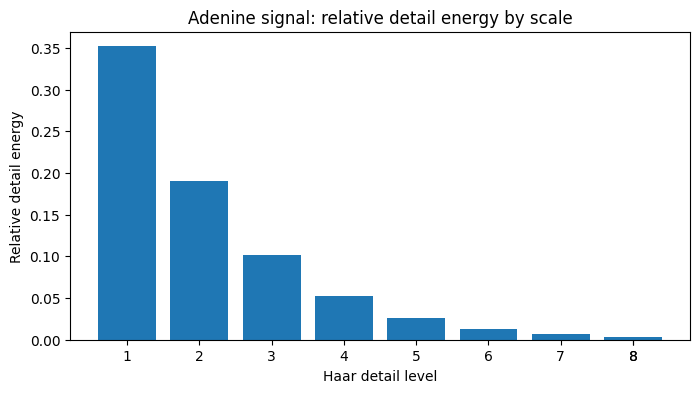

In [18]:
plt.figure(figsize=(8, 4))
plt.bar(a_energy["level"].iloc[1:], a_energy["relative_energy"].iloc[1:])
plt.xlabel("Haar detail level")
plt.ylabel("Relative detail energy")
plt.title("Adenine signal: relative detail energy by scale")
plt.xticks(a_energy["level"])
plt.show()

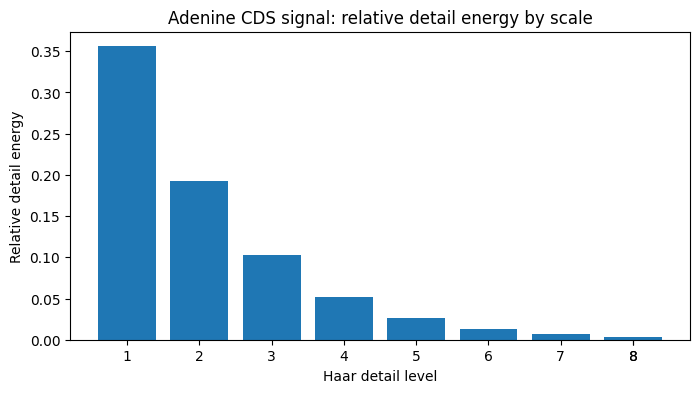

In [19]:
plt.figure(figsize=(8, 4))
plt.bar(a_cds_energy["level"].iloc[1:], a_cds_energy["relative_energy"].iloc[1:])
plt.xlabel("Haar detail level")
plt.ylabel("Relative detail energy")
plt.title("Adenine CDS signal: relative detail energy by scale")
plt.xticks(a_cds_energy["level"])
plt.show()

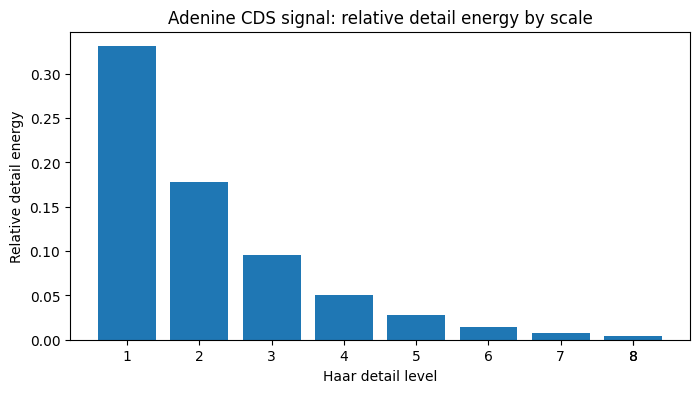

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(a_noncds_energy["level"].iloc[1:], a_noncds_energy["relative_energy"].iloc[1:])
plt.xlabel("Haar detail level")
plt.ylabel("Relative detail energy")
plt.title("Adenine CDS signal: relative detail energy by scale")
plt.xticks(a_noncds_energy["level"])
plt.show()

In [21]:
pd.DataFrame({
    "full": a_energy["relative_energy"][a_energy["kind"]=="detail"],
    "cds": a_cds_energy["relative_energy"][a_cds_energy["kind"]=="detail"],
    "noncds": a_noncds_energy["relative_energy"][a_noncds_energy["kind"]=="detail"],
})

,full,cds,noncds
1,0.351781,0.355920,0.330846
2,0.190435,0.192664,0.177870
3,0.101630,0.102825,0.096120
4,0.052126,0.052085,0.050569
5,0.026282,0.026191,0.027563
6,0.013372,0.013067,0.014639
7,0.006628,0.006513,0.007877
8,0.003571,0.003344,0.004367


## CDS vs Non-CDS Energy Comparison

Let's look at distribution differences using KL divergence (which is directional), Jensen-Shannon divergence, L2 distance, total variation distance, and a per-level absolute-difference table.


In [22]:
cds_detail_profile = a_cds_detail_energy[["level", "energy"]].copy().sort_values("level", ascending=False)
noncds_detail_profile = a_noncds_detail_energy[["level", "energy"]].copy().sort_values("level", ascending=False)

# Renormalize over detail levels only so the comparison is between detail-energy profiles.
cds_detail_profile["relative_energy"] = cds_detail_profile["energy"] / cds_detail_profile["energy"].sum()
noncds_detail_profile["relative_energy"] = noncds_detail_profile["energy"] / noncds_detail_profile["energy"].sum()
cds_detail_profile["kind"] = "detail"
noncds_detail_profile["kind"] = "detail"

detail_energy_comparison = cds_detail_profile.merge(
    noncds_detail_profile,
    on="level",
    suffixes=("_cds", "_noncds"),
).sort_values("level", ascending=False)

detail_energy_comparison["absolute_difference"] = (
    detail_energy_comparison["relative_energy_cds"]
    - detail_energy_comparison["relative_energy_noncds"]
).abs()

kl_cds_to_noncds = compare_energy_profiles(
    cds_detail_profile,
    noncds_detail_profile,
    column="relative_energy",
    metric="kl",
)
kl_noncds_to_cds = compare_energy_profiles(
    noncds_detail_profile,
    cds_detail_profile,
    column="relative_energy",
    metric="kl",
)
js_cds_noncds = compare_energy_profiles(
    cds_detail_profile,
    noncds_detail_profile,
    column="relative_energy",
    metric="js",
)
l2_cds_noncds = compare_energy_profiles(
    cds_detail_profile,
    noncds_detail_profile,
    column="relative_energy",
    metric="l2",
)
total_variation_cds_noncds = 0.5 * detail_energy_comparison["absolute_difference"].sum()

print("CDS vs non-CDS detail-energy divergence summary")
print(f"KL(CDS || non-CDS): {kl_cds_to_noncds:.6f}")
print(f"KL(non-CDS || CDS): {kl_noncds_to_cds:.6f}")
print(f"JS(CDS, non-CDS): {js_cds_noncds:.6f}")
print(f"L2 distance: {l2_cds_noncds:.6f}")
print(f"Total variation distance: {total_variation_cds_noncds:.6f}")

detail_energy_comparison[[
    "level",
    "relative_energy_cds",
    "relative_energy_noncds",
    "absolute_difference",
]]


CDS vs non-CDS detail-energy divergence summary
KL(CDS || non-CDS): 0.001711
KL(non-CDS || CDS): 0.001826
JS(CDS, non-CDS): 0.000441
L2 distance: 0.010839
Total variation distance: 0.013474


,level,relative_energy_cds,relative_energy_noncds,absolute_difference
0,8,0.004443,0.006153,0.001710
1,7,0.008654,0.011096,0.002442
2,6,0.017362,0.020623,0.003261
3,5,0.034801,0.038829,0.004028
4,4,0.069206,0.071239,0.002033
5,3,0.136625,0.135409,0.001216
6,2,0.255995,0.250574,0.005421
7,1,0.472915,0.466078,0.006837


In [57]:
detail_powerlaw_profiles = {
    "full": a_detail_energy[["level", "energy"]].copy(),
    "CDS": a_cds_detail_energy[["level", "energy"]].copy(),
    "non-CDS": a_noncds_detail_energy[["level", "energy"]].copy(),
}

powerlaw_rows = []
for signal_name, profile in detail_powerlaw_profiles.items():
    fit_df = profile.sort_values("level").copy()
    fit_df["relative_energy"] = fit_df["energy"] / fit_df["energy"].sum()
    fit_df["scale_bp"] = 2 ** fit_df["level"]

    x_log = np.log(fit_df["scale_bp"].to_numpy(dtype=float))
    y_log = np.log(fit_df["relative_energy"].to_numpy(dtype=float))

    power_law_slope, power_law_intercept = np.polyfit(x_log, y_log, 1)
    y_log_hat_power = power_law_slope * x_log + power_law_intercept
    ss_tot = np.sum((y_log - y_log.mean()) ** 2)
    ss_res_power = np.sum((y_log - y_log_hat_power) ** 2)
    power_law_r2 = 1 - ss_res_power / ss_tot if ss_tot > 0 else np.nan

    x_linear = fit_df["scale_bp"].to_numpy(dtype=float)
    exp_slope, exp_intercept = np.polyfit(x_linear, y_log, 1)
    y_log_hat_exp = exp_slope * x_linear + exp_intercept
    ss_res_exp = np.sum((y_log - y_log_hat_exp) ** 2)
    exp_r2 = 1 - ss_res_exp / ss_tot if ss_tot > 0 else np.nan

    powerlaw_rows.append({
        "signal": signal_name,
        "power_law_exponent": power_law_slope,
        "power_law_r2": power_law_r2,
        "semilog_r2": exp_r2,
    })

powerlaw_summary = pd.DataFrame(powerlaw_rows)
print("Detail-energy scaling fit summary")
display(powerlaw_summary)


Detail-energy scaling fit summary


,signal,power_law_exponent,power_law_r2,semilog_r2
0,full,-0.956470,0.999650,0.728279
1,CDS,-0.970136,0.999566,0.733971
2,non-CDS,-0.895344,0.999943,0.717992


### Power Law Fit Results
Values close to 1 indicate that the signal follows power-law-type scaling well across the detail levels.

Since power_law_r2 is larger than semilog_r2, that is evidence that the log-log power-law model is a better description than a semilog exponential-style model.

## Detail Energies Results
The shape of each signal looks very similar, monotonically decreasing from high frequency detail level 1 (2 base pairs) to lower frequency detail level 8 (256 base pairs).  It looks like we're roughly halving at each level, which appears to be a sort of power law.

### Takeaways
- Energy profile looks similar between CDS and Non-CDS averaged across the entirety of the genome
- The biggest differences are at the finest scales, though they appear to be small

## Windowed Wavelet Energy

Let's look at local windows of the genome to study how multiscale structure changes across position.

In [23]:
a_windowed_energy = compute_windowed_wavelet_energy(
    a_signal,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
    wavelet="haar",
    level=WINDOW_LEVEL,
    normalize=True,
    include_approximation=False,
)

window_cds = summarize_window_cds_fraction(
    cds_mask,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
)

a_windowed_energy = a_windowed_energy.merge(
    window_cds,
    on=["window_start", "window_end"],
    how="left",
)

a_windowed_energy.head()

,kind,level,energy,relative_energy,window_start,window_end,cds_fraction
0,detail,1,326.000,0.454187,0,4096,0.933838
1,detail,2,190.000,0.264710,0,4096,0.933838
2,detail,3,99.000,0.137928,0,4096,0.933838
3,detail,4,50.875,0.070880,0,4096,0.933838
4,detail,5,31.000,0.043190,0,4096,0.933838


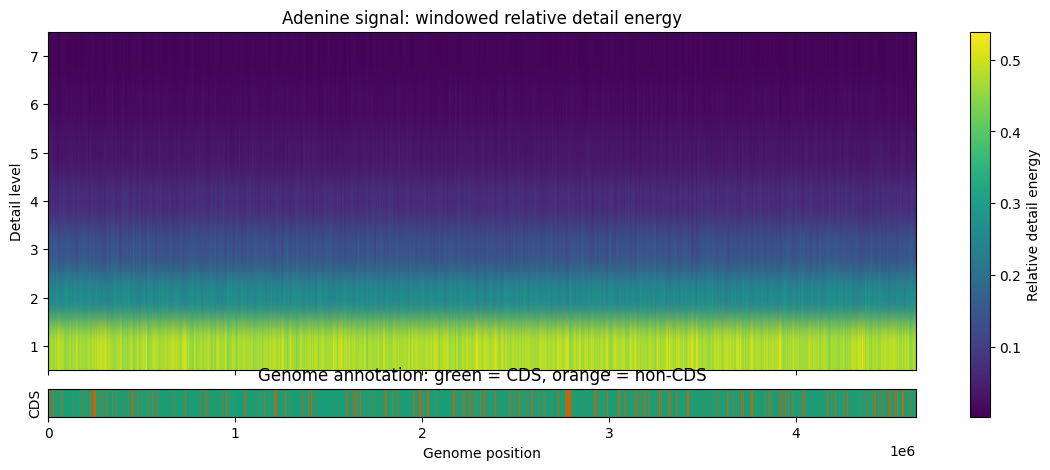

In [42]:
heatmap_df = (
    a_windowed_energy[a_windowed_energy["kind"] == "detail"]
    .pivot(index="level", columns="window_start", values="relative_energy")
    .sort_index()
)

window_positions = (
    a_windowed_energy[["window_start", "window_end"]]
    .drop_duplicates()
    .sort_values("window_start")
)
x_min = int(window_positions["window_start"].iloc[0])
x_max = int(window_positions["window_end"].iloc[-1])
heatmap_extent = [x_min, x_max, heatmap_df.index.min() - 0.5, heatmap_df.index.max() + 0.5]

region_strip = cds_mask.astype(int).reshape(1, -1)
region_cmap = plt.matplotlib.colors.ListedColormap([
    (0.85, 0.37, 0.01),
    (0.10, 0.62, 0.47),
])

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Adenine signal: windowed relative detail energy")

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(x_min, x_max)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

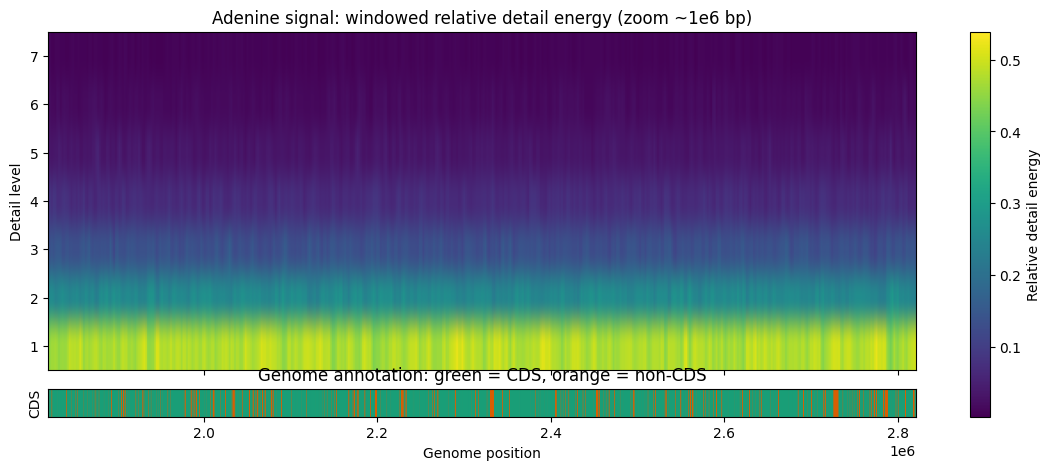

In [43]:
zoom_width = int(1e6)
zoom_center = genome_len // 2
zoom_start = max(0, zoom_center - zoom_width // 2)
zoom_end = min(genome_len, zoom_start + zoom_width)
zoom_start = max(0, zoom_end - zoom_width)

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Adenine signal: windowed relative detail energy (zoom ~1e6 bp)")
ax_heatmap.set_xlim(zoom_start, zoom_end)

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(zoom_start, zoom_end)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

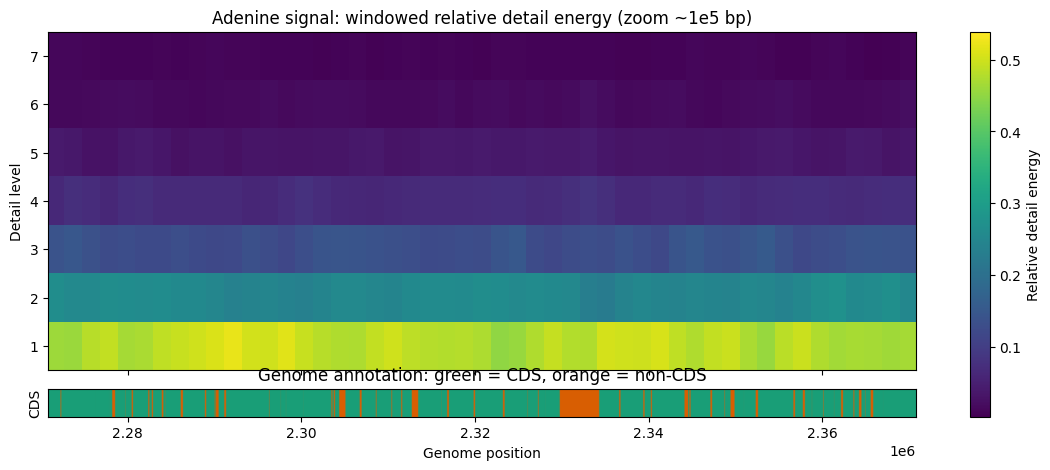

In [44]:
zoom_width = int(1e5)
zoom_center = genome_len // 2
zoom_start = max(0, zoom_center - zoom_width // 2)
zoom_end = min(genome_len, zoom_start + zoom_width)
zoom_start = max(0, zoom_end - zoom_width)

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Adenine signal: windowed relative detail energy (zoom ~1e5 bp)")
ax_heatmap.set_xlim(zoom_start, zoom_end)

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(zoom_start, zoom_end)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

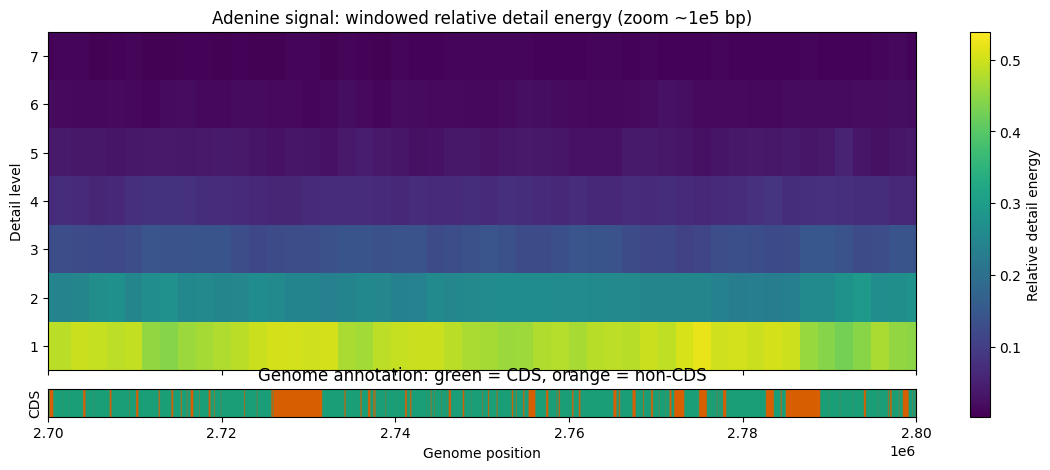

In [49]:
zoom_width = int(1e5)
zoom_center = genome_len // 2
zoom_start = 2.7 * 1e6
zoom_end = min(genome_len, zoom_start + zoom_width)
zoom_start = max(0, zoom_end - zoom_width)

fig, (ax_heatmap, ax_region) = plt.subplots(
    2,
    1,
    figsize=(14, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [12, 1], "hspace": 0.10},
)

im = ax_heatmap.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    extent=heatmap_extent,
)
fig.colorbar(im, ax=[ax_heatmap, ax_region], label="Relative detail energy")
ax_heatmap.set_yticks(heatmap_df.index)
ax_heatmap.set_ylabel("Detail level")
ax_heatmap.set_title("Adenine signal: windowed relative detail energy (zoom ~1e5 bp)")
ax_heatmap.set_xlim(zoom_start, zoom_end)

ax_region.imshow(
    region_strip,
    aspect="auto",
    origin="lower",
    extent=[0, len(cds_mask), 0, 1],
    cmap=region_cmap,
    vmin=0,
    vmax=1,
)
ax_region.set_xlim(zoom_start, zoom_end)
ax_region.set_yticks([])
ax_region.set_ylabel("CDS")
ax_region.set_xlabel("Genome position")
ax_region.set_title("Genome annotation: green = CDS, orange = non-CDS")

plt.show()

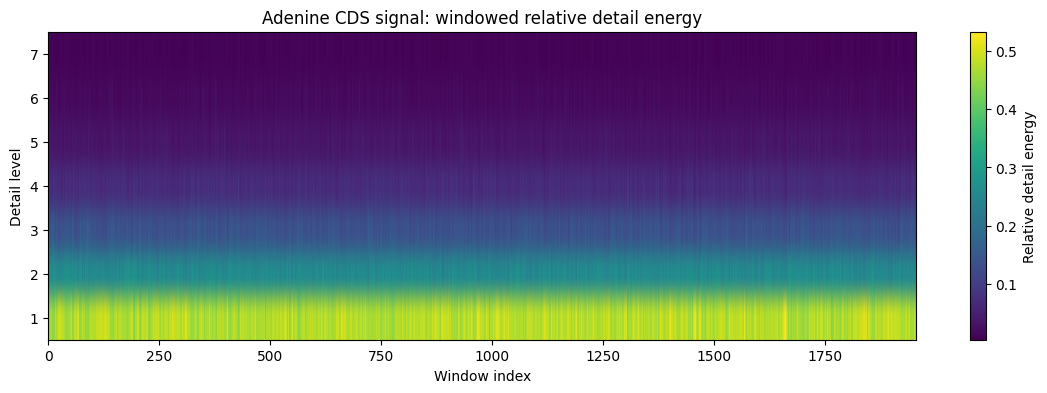

In [25]:
heatmap_cds_df = (
    a_cds_windowed_energy[a_cds_windowed_energy["kind"] == "detail"]
    .pivot(index="level", columns="window_start", values="relative_energy")
    .sort_index()
)

plt.figure(figsize=(14, 4))
plt.imshow(heatmap_cds_df.values, aspect="auto", origin="lower")
plt.colorbar(label="Relative detail energy")
plt.yticks(
    ticks=np.arange(len(heatmap_cds_df.index)),
    labels=heatmap_cds_df.index,
)
plt.xlabel("Window index")
plt.ylabel("Detail level")
plt.title("Adenine CDS signal: windowed relative detail energy")
plt.show()

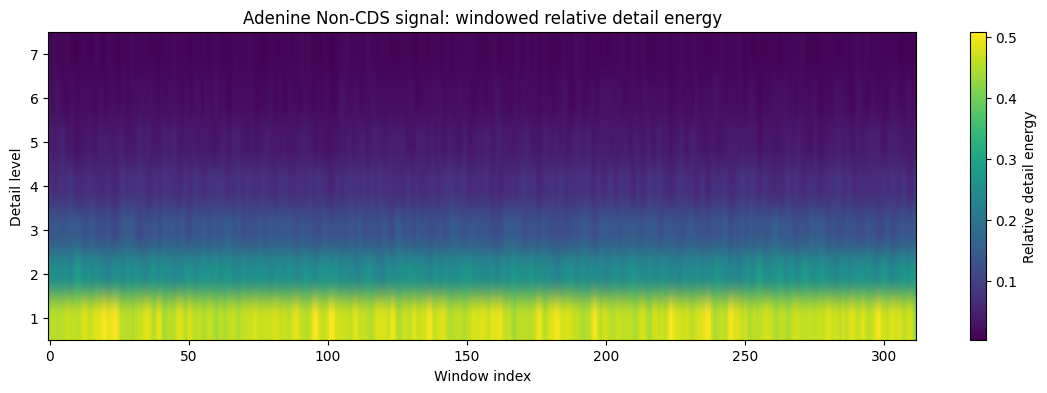

In [39]:
heatmap_noncds_df = (
    a_noncds_windowed_energy[a_noncds_windowed_energy["kind"] == "detail"]
    .pivot(index="level", columns="window_start", values="relative_energy")
    .sort_index()
)

plt.figure(figsize=(14, 4))
plt.imshow(heatmap_noncds_df.values, aspect="auto", origin="lower")
plt.colorbar(label="Relative detail energy")
plt.yticks(
    ticks=np.arange(len(heatmap_noncds_df.index)),
    labels=heatmap_noncds_df.index,
)
plt.xlabel("Window index")
plt.ylabel("Detail level")
plt.title("Adenine Non-CDS signal: windowed relative detail energy")
plt.show()

In [27]:
window_detail_df = a_windowed_energy[a_windowed_energy["kind"] == "detail"].copy()

window_level_correlations = (
    window_detail_df.groupby("level")
    .apply(
        lambda group: pd.Series({
            "pearson_corr": group["cds_fraction"].corr(group["relative_energy"], method="pearson"),
            "spearman_corr": group["cds_fraction"].corr(group["relative_energy"], method="spearman"),
            "mean_relative_energy": group["relative_energy"].mean(),
            "std_relative_energy": group["relative_energy"].std(),
        })
    )
    .reset_index()
    .sort_values("level", ascending=False)
)

window_detail_df["window_class"] = window_detail_df["cds_fraction"].apply(
    lambda x: "CDS" if x >= 0.8 else ("non-CDS" if x <= 0.2 else "mixed")
)

window_distribution_summary = (
    window_detail_df[window_detail_df["window_class"].isin(["CDS", "non-CDS"])]
    .groupby(["level", "window_class"])["relative_energy"]
    .agg([
        "count",
        "mean",
        "std",
        "median",
        lambda s: s.quantile(0.75) - s.quantile(0.25),
    ])
    .rename(columns={"<lambda_0>": "iqr"})
    .reset_index()
)

print("Per-level correlation between CDS fraction and relative detail energy")
display(window_level_correlations)

print("Distribution summary for CDS vs non-CDS windows")
display(window_distribution_summary)


Per-level correlation between CDS fraction and relative detail energy


,level,pearson_corr,spearman_corr,mean_relative_energy,std_relative_energy
6,7,-0.059873,-0.131237,0.008927,0.002380
5,6,-0.049888,-0.110151,0.018000,0.003505
4,5,-0.050852,-0.084248,0.035398,0.004671
3,4,0.038394,-0.007074,0.070202,0.006625
2,3,0.072584,0.066072,0.136960,0.009522
1,2,0.047536,0.094270,0.256609,0.010938
0,1,-0.053959,-0.041874,0.473904,0.016877


Distribution summary for CDS vs non-CDS windows


,level,window_class,count,mean,std,median,iqr
0,1,CDS,1864,0.473501,0.016888,0.473199,0.022687
1,1,non-CDS,16,0.475724,0.022275,0.460713,0.044316
2,2,CDS,1864,0.256886,0.010605,0.256738,0.014092
3,2,non-CDS,16,0.263475,0.017357,0.263924,0.028972
4,3,CDS,1864,0.137358,0.009514,0.137464,0.012712
5,3,non-CDS,16,0.138997,0.014609,0.136445,0.019069
6,4,CDS,1864,0.070267,0.006582,0.070073,0.008938
7,4,non-CDS,16,0.062893,0.007290,0.060058,0.009206
8,5,CDS,1864,0.035311,0.004665,0.035115,0.006365
9,5,non-CDS,16,0.034414,0.005314,0.036029,0.008660


## Windowed Energies Results

The heat maps are useful for qualitative inspection, but they are hard to compare visually because they contain a lot of fine structure. Looking at the quantitative correlation and distribution metrics:
- per-level Pearson and Spearman correlations between CDS fraction and relative detail energy are very small
- There is a strong imbalance between the number of windows, so I'm not sure how much we can glean from the distribution comparison metrics


## Figure: Boxplots of Relative Detail Energy by Scale

Let's create a statistical comparison between coding and non-coding regions for the Adenine signal.

In [28]:
def classify_cds_window(cds_fraction: float) -> str:
    if cds_fraction >= 0.8:
        return "CDS"
    if cds_fraction <= 0.2:
        return "non-CDS"
    return "mixed"

a_windowed_energy["window_class"] = a_windowed_energy["cds_fraction"].apply(classify_cds_window)

comparison_df = a_windowed_energy[
    (a_windowed_energy["kind"] == "detail") &
    (a_windowed_energy["window_class"].isin(["CDS", "non-CDS"]))
].copy()

comparison_df.head()

,kind,level,energy,relative_energy,window_start,window_end,cds_fraction,window_class
0,detail,1,326.000,0.454187,0,4096,0.933838,CDS
1,detail,2,190.000,0.264710,0,4096,0.933838,CDS
2,detail,3,99.000,0.137928,0,4096,0.933838,CDS
3,detail,4,50.875,0.070880,0,4096,0.933838,CDS
4,detail,5,31.000,0.043190,0,4096,0.933838,CDS


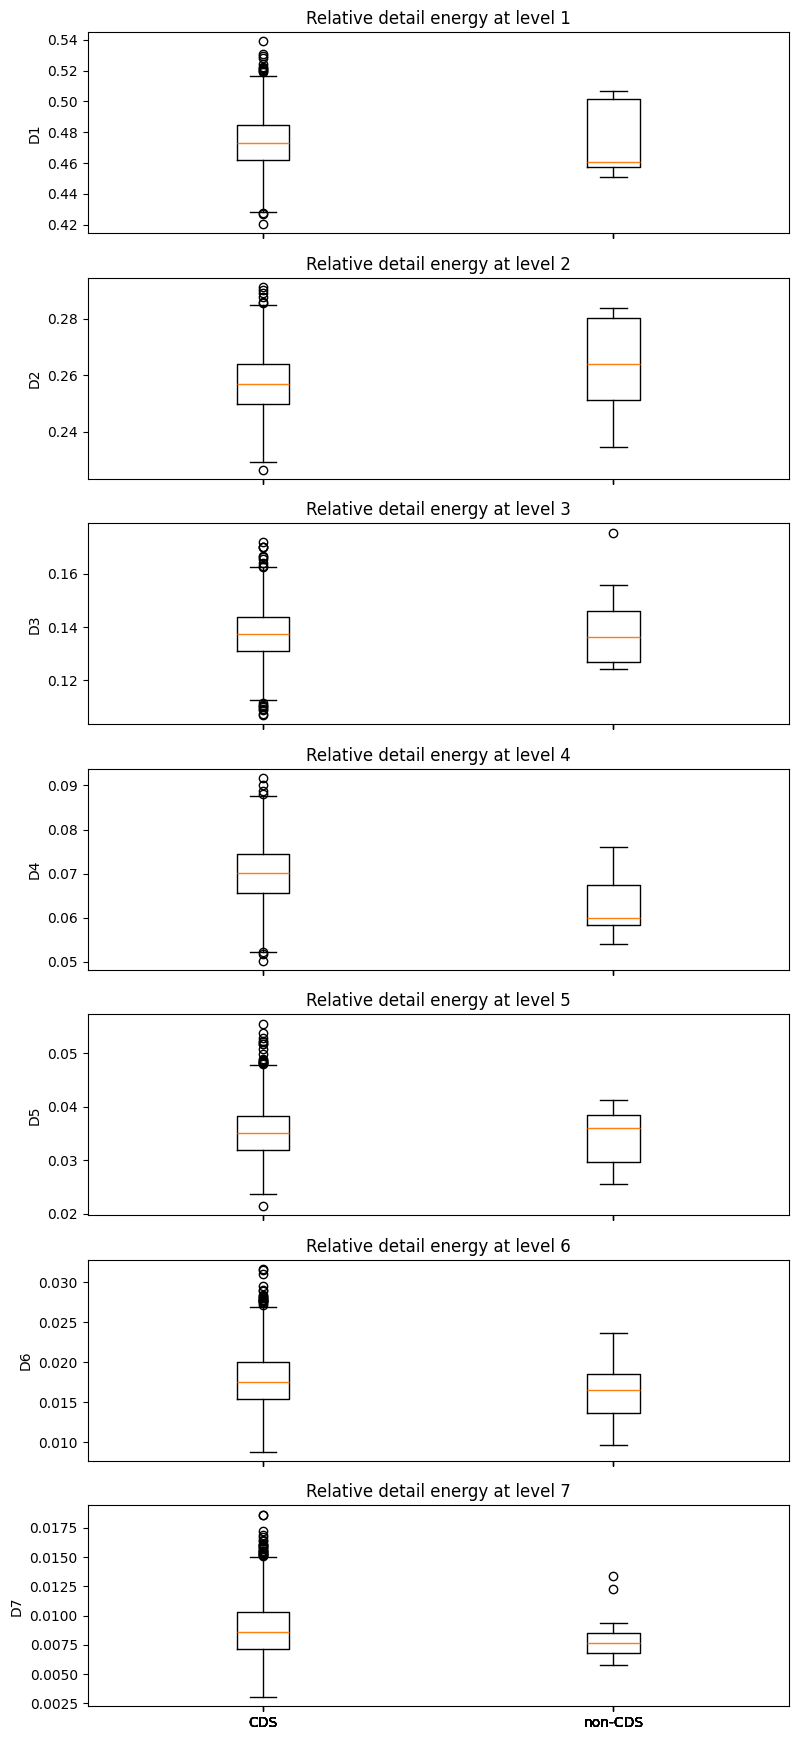

In [29]:
levels = sorted(comparison_df["level"].unique())
fig, axes = plt.subplots(len(levels), 1, figsize=(8, 2.5 * len(levels)), sharex=True)

if len(levels) == 1:
    axes = [axes]

for ax, level in zip(axes, levels):
    subset = comparison_df[comparison_df["level"] == level]
    groups = [
        subset[subset["window_class"] == "CDS"]["relative_energy"].dropna(),
        subset[subset["window_class"] == "non-CDS"]["relative_energy"].dropna(),
    ]
    ax.boxplot(groups, tick_labels=["CDS", "non-CDS"])
    ax.set_ylabel(f"D{level}")
    ax.set_title(f"Relative detail energy at level {level}")

plt.tight_layout()
plt.show()

### Box Plots Results
As expected, with less of the genome in the Non-CDS bucket, the variance is a bit higher.  I think we would also likely expect this apriori under the hypothesis that coding regions might have more structure.  Interestingly, at the coursest levels, the Non-CDS IQR appears to have a much narrower spread.

## Window-Level Entropy of Scale-Energy Distribution

Let's look at each window's multiscale energy distribution with a single scalar measuring the entropy.
- Lower entropy means the window's energy is concentrated in fewer scales.
- Higher entropy means the energy is spread more evenly across scales.

In [30]:
window_entropy_rows = []

for (window_start, window_end), group in (
    a_windowed_energy[a_windowed_energy["kind"] == "detail"]
    .groupby(["window_start", "window_end"])
):
    entropy = compute_scale_entropy(group, column="relative_energy")
    cds_fraction = float(group["cds_fraction"].iloc[0])
    window_entropy_rows.append({
        "window_start": window_start,
        "window_end": window_end,
        "cds_fraction": cds_fraction,
        "window_class": classify_cds_window(cds_fraction),
        "scale_entropy": entropy,
    })

a_window_entropy = pd.DataFrame(window_entropy_rows)
a_window_entropy.head()

,window_start,window_end,cds_fraction,window_class,scale_entropy
0,0,4096,0.933838,CDS,2.060980
1,2048,6144,0.910645,CDS,2.060050
2,4096,8192,0.837158,CDS,2.074935
3,6144,10240,0.879150,CDS,2.062579
4,8192,12288,0.818848,CDS,2.050497


/var/folders/v3/_ft619t917q63j9n5v6t883h000_8v/T/ipykernel_20072/3393901642.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["CDS", "non-CDS"])


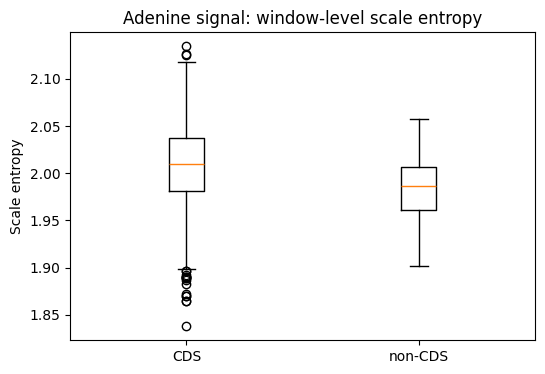

In [31]:
entropy_compare = a_window_entropy[
    a_window_entropy["window_class"].isin(["CDS", "non-CDS"])
]

plt.figure(figsize=(6, 4))
groups = [
    entropy_compare[entropy_compare["window_class"] == "CDS"]["scale_entropy"].dropna(),
    entropy_compare[entropy_compare["window_class"] == "non-CDS"]["scale_entropy"].dropna(),
]
plt.boxplot(groups, labels=["CDS", "non-CDS"])
plt.ylabel("Scale entropy")
plt.title("Adenine signal: window-level scale entropy")
plt.show()

In [32]:
cds_entropy_mean = entropy_compare[entropy_compare["window_class"] == "CDS"]["scale_entropy"].dropna().mean()
cds_entropy_std = entropy_compare[entropy_compare["window_class"] == "CDS"]["scale_entropy"].dropna().std()
noncds_entropy_mean = entropy_compare[entropy_compare["window_class"] == "non-CDS"]["scale_entropy"].dropna().mean()
noncds_entropy_std = entropy_compare[entropy_compare["window_class"] == "non-CDS"]["scale_entropy"].dropna().std()
print(f"cds_entropy_mean, std {cds_entropy_mean}, {cds_entropy_std}")
print(f"noncds_entropy_mean, std {noncds_entropy_mean}, {noncds_entropy_std}")

cds_entropy_mean, std 2.0081887328235624, 0.04211567754969268
noncds_entropy_mean, std 1.9798106610551653, 0.041005551790437876


### Let's look at how "significant" the entropy delta is
We can look at how many standard deviations from CDS the Non-CDS entropy is

In [58]:
entropy_delta = cds_entropy_mean - noncds_entropy_mean
relative_entropy_delta = entropy_delta / cds_entropy_mean
cds_entropy_values = entropy_compare[
    entropy_compare["window_class"] == "CDS"
]["scale_entropy"].dropna().to_numpy()
noncds_entropy_values = entropy_compare[
    entropy_compare["window_class"] == "non-CDS"
]["scale_entropy"].dropna().to_numpy()
n_cds = len(cds_entropy_values)
n_noncds = len(noncds_entropy_values)
pooled_entropy_std = np.sqrt(
    (
        (n_cds - 1) * cds_entropy_std**2
        + (n_noncds - 1) * noncds_entropy_std**2
    )
    / (n_cds + n_noncds - 2)
)
cohens_d_entropy = entropy_delta / pooled_entropy_std
entropy_delta_std = entropy_delta / noncds_entropy_std
print(f"entropy_delta {entropy_delta}, relative_entropy_delta {relative_entropy_delta}")
print(f"entropy_delta_std {entropy_delta_std}")
print(f"cohens_d_entropy {cohens_d_entropy}")

entropy_delta 0.028378071768397017, relative_entropy_delta 0.014131177665007988
entropy_delta_std 0.6920543811585661
cohens_d_entropy 0.6739525775190557


### Entropy Results (no error bars)
At roughly 0.69 standard deviations, the difference between the cds and non-cds entropy appears somewhat significant, with more entropy in the CDS regions.  As mentioned, this indicates that the CDS signal is "spread more evenly" across the scales.  This was a bit surprising to me, as I would have thought that it would be more concentrated at the finer scales due to codon patterns.

We quantify the effect size with the standard "cohen's d score", which is a very similar calculation to the original "entropy_delta_std", just a little more mathematically rigorous.  This is a solidly moderate (nearly large) effect size.

### Let's put error bars on the entropy calculations
We can use bootstrapping (sample with replacement) and empirically derive the 95% confidence intervals.

In [50]:
def bootstrap_mean_ci(values, n_boot=1000, alpha=0.05, random_state=0):
    rng = np.random.default_rng(random_state)
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(sample.mean())

    lower = np.percentile(boot_means, 100 * (alpha / 2))
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return values.mean(), lower, upper

entropy_bootstrap_rows = []
for window_class in ["CDS", "non-CDS"]:
    values = entropy_compare[
        entropy_compare["window_class"] == window_class
    ]["scale_entropy"].to_numpy()
    mean_entropy, ci_lower, ci_upper = bootstrap_mean_ci(values)
    entropy_bootstrap_rows.append({
        "window_class": window_class,
        "mean_entropy": mean_entropy,
        "bootstrap_ci_lower": ci_lower,
        "bootstrap_ci_upper": ci_upper,
    })

entropy_bootstrap_summary = pd.DataFrame(entropy_bootstrap_rows)
print("Bootstrap 95 percent confidence intervals for mean window entropy")
display(entropy_bootstrap_summary)


Bootstrap 95 percent confidence intervals for mean window entropy


,window_class,mean_entropy,bootstrap_ci_lower,bootstrap_ci_upper
0,CDS,2.008189,2.00636,2.010071
1,non-CDS,1.979811,1.95979,1.998388


In [53]:
best_entropy_delta = entropy_bootstrap_summary.iloc[0].loc["bootstrap_ci_lower"] - entropy_bootstrap_summary.iloc[1].loc["bootstrap_ci_upper"]
best_relative_entropy_delta = best_entropy_delta / cds_entropy_mean
best_entropy_delta_std = best_entropy_delta / noncds_entropy_std
print(f"best_entropy_delta {best_entropy_delta}, best_relative_entropy_delta {best_relative_entropy_delta}")
print(f"best_entropy_delta_std {best_entropy_delta_std}")

best_entropy_delta 0.007971501233068112, best_relative_entropy_delta 0.0039694980370993255
best_entropy_delta_std 0.1944005356593444


### Entropy Results (error bars)
Using the high end of Non-CDS 95% error and the low end of CDS 95% error, we can get an entropy difference as low as 0.19 standard deviations.

## Reconstruction Error Analysis

Let's quantify how well the full Adenine signal can be recovered from wavelet reconstructions using the L2 norm. We use the maximum admissible decomposition level for the full signal, then look at two reconstruction strategies:
- approximation-only reconstructions at each level
- cumulative reconstructions built from the coarsest approximation plus progressively more detail levels


In [34]:
full_a_max_level = max_wavelet_level(len(a_signal), MOTHER_WAVELET)
a_full_error_artifacts = prepare_wavelet_artifacts(
    a_signal,
    wavelet=MOTHER_WAVELET,
    level=full_a_max_level,
    reconstruct_components=True,
)

x_full = a_full_error_artifacts["decomposition"]["signal"]
A_full = a_full_error_artifacts["reconstructions"]["approximations"]
D_full = a_full_error_artifacts["reconstructions"]["details"]
J_full = a_full_error_artifacts["decomposition"]["level"]
x_full_norm = np.linalg.norm(x_full)

approximation_error_rows = []
for level in sorted(A_full.keys()):
    approximation_reconstruction = A_full[level]
    l2_error = np.linalg.norm(x_full - approximation_reconstruction)
    approximation_error_rows.append({
        "level": level,
        "stage": f"A{level}",
        "l2_error": l2_error,
        "relative_l2_error": l2_error / x_full_norm,
    })

approximation_error_df = pd.DataFrame(approximation_error_rows).sort_values("level")

cumulative_error_rows = []
current_reconstruction = A_full[J_full].copy()
l2_error = np.linalg.norm(x_full - current_reconstruction)
cumulative_error_rows.append({
    "num_detail_levels_included": 0,
    "lowest_detail_level_included": None,
    "stage": f"A{J_full}",
    "l2_error": l2_error,
    "relative_l2_error": l2_error / x_full_norm,
})

for count, level in enumerate(range(J_full, 0, -1), start=1):
    current_reconstruction = current_reconstruction + D_full[level]
    l2_error = np.linalg.norm(x_full - current_reconstruction)
    included_details = [f"D{k}" for k in range(J_full, level - 1, -1)]
    cumulative_error_rows.append({
        "num_detail_levels_included": count,
        "lowest_detail_level_included": level,
        "stage": f"A{J_full} + " + " + ".join(included_details),
        "l2_error": l2_error,
        "relative_l2_error": l2_error / x_full_norm,
    })

cumulative_error_df = pd.DataFrame(cumulative_error_rows)

print(f"Maximum decomposition level for the full Adenine signal: {J_full}")
display(approximation_error_df)
display(cumulative_error_df)


Maximum decomposition level for the full Adenine signal: 22


,level,stage,l2_error,relative_l2_error
0,1,A1,634.033911,0.593114
1,2,A2,787.158815,0.736357
2,3,A3,857.762933,0.802404
3,4,A4,891.809817,0.834254
4,5,A5,908.492398,0.849860
5,6,A6,916.863267,0.857690
6,7,A7,920.985011,0.861546
7,8,A8,923.197877,0.863616
8,9,A9,924.567261,0.864897
9,10,A10,925.540877,0.865808


,num_detail_levels_included,lowest_detail_level_included,stage,l2_error,relative_l2_error
0,0,NaN,A22,9.281185e+02,8.682191e-01
1,1,22.0,A22 + D22,9.281182e+02,8.682188e-01
2,2,21.0,A22 + D22 + D21,9.280941e+02,8.681962e-01
3,3,20.0,A22 + D22 + D21 + D20,9.280880e+02,8.681906e-01
4,4,19.0,A22 + D22 + D21 + D20 + D19,9.280720e+02,8.681756e-01
5,5,18.0,A22 + D22 + D21 + D20 + D19 + D18,9.280292e+02,8.681356e-01
6,6,17.0,A22 + D22 + D21 + D20 + D19 + D18 + D17,9.279700e+02,8.680802e-01
7,7,16.0,A22 + D22 + D21 + D20 + D19 + D18 + D17 + D16,9.278562e+02,8.679738e-01
8,8,15.0,A22 + D22 + D21 + D20 + D19 + D18 + D17 + D16 ...,9.276339e+02,8.677658e-01
9,9,14.0,A22 + D22 + D21 + D20 + D19 + D18 + D17 + D16 ...,9.273578e+02,8.675075e-01


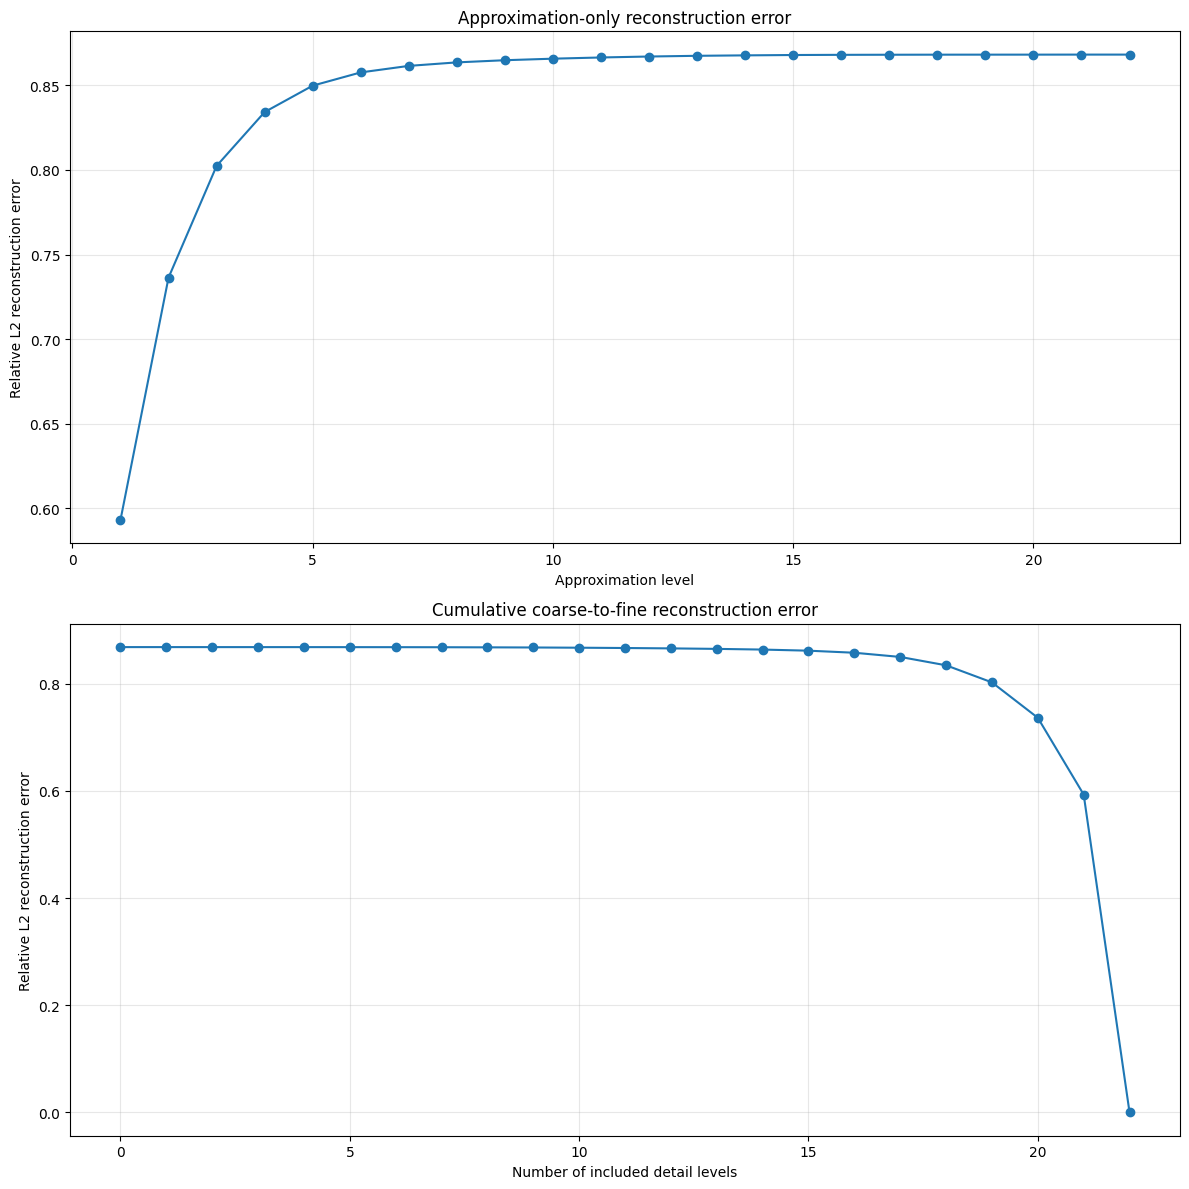

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

axes[0].plot(
    approximation_error_df["level"],
    approximation_error_df["relative_l2_error"],
    marker="o",
)
axes[0].set_xlabel("Approximation level")
axes[0].set_ylabel("Relative L2 reconstruction error")
axes[0].set_title("Approximation-only reconstruction error")
axes[0].grid(alpha=0.3)

axes[1].plot(
    cumulative_error_df["num_detail_levels_included"],
    cumulative_error_df["relative_l2_error"],
    marker="o",
)
axes[1].set_xlabel("Number of included detail levels")
axes[1].set_ylabel("Relative L2 reconstruction error")
axes[1].set_title("Cumulative coarse-to-fine reconstruction error")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


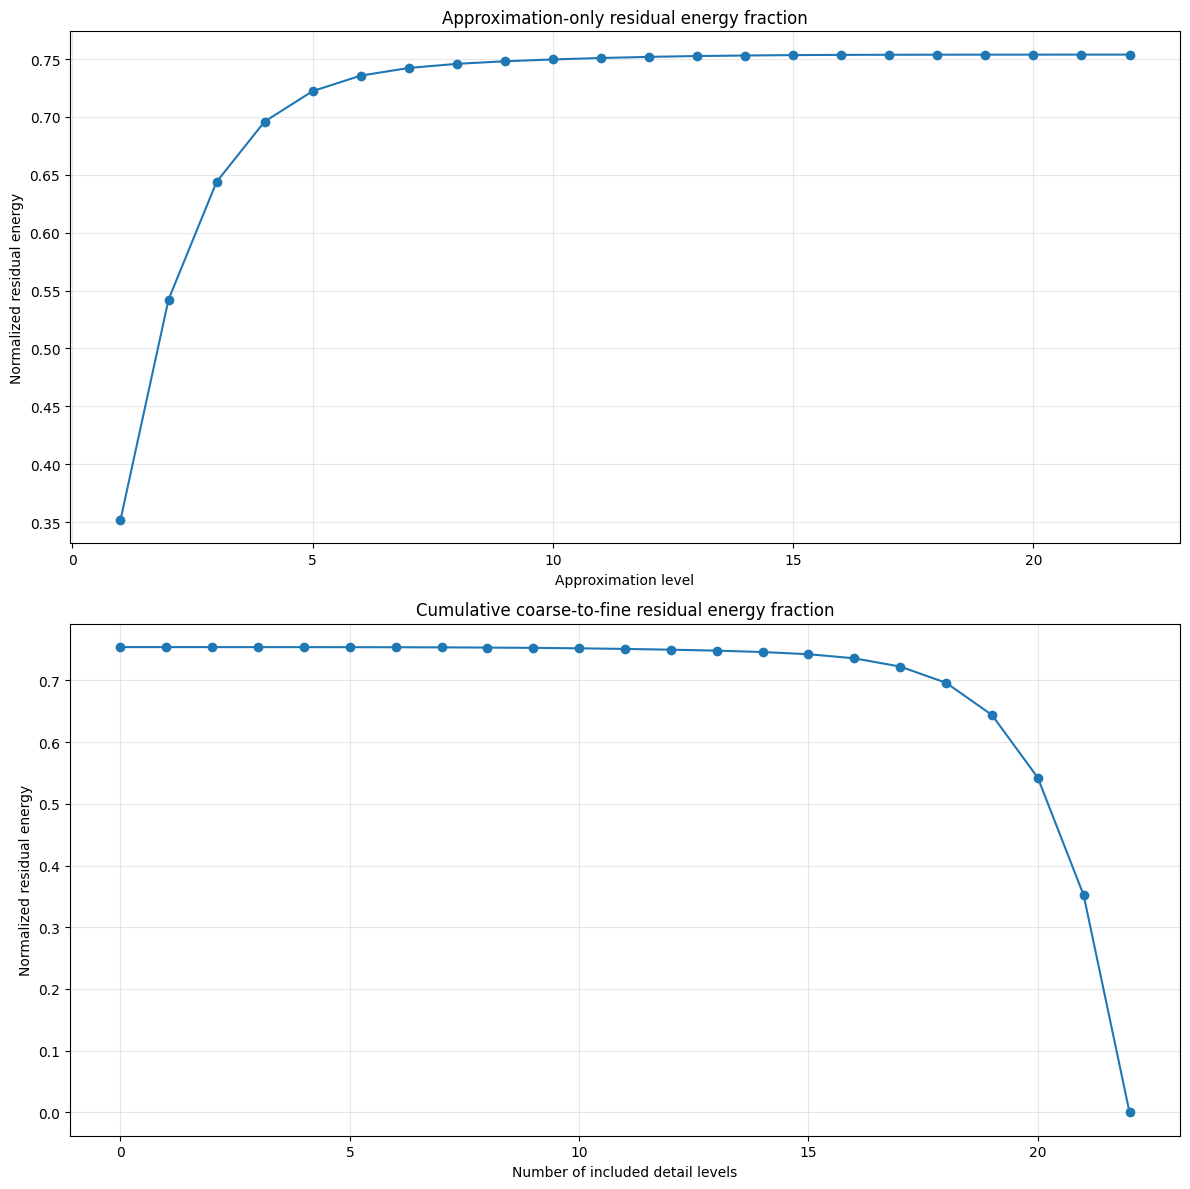

In [36]:
approximation_error_df["normalized_residual_energy"] = approximation_error_df["relative_l2_error"] ** 2
cumulative_error_df["normalized_residual_energy"] = cumulative_error_df["relative_l2_error"] ** 2

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

axes[0].plot(
    approximation_error_df["level"],
    approximation_error_df["normalized_residual_energy"],
    marker="o",
)
axes[0].set_xlabel("Approximation level")
axes[0].set_ylabel("Normalized residual energy")
axes[0].set_title("Approximation-only residual energy fraction")
axes[0].grid(alpha=0.3)

axes[1].plot(
    cumulative_error_df["num_detail_levels_included"],
    cumulative_error_df["normalized_residual_energy"],
    marker="o",
)
axes[1].set_xlabel("Number of included detail levels")
axes[1].set_ylabel("Normalized residual energy")
axes[1].set_title("Cumulative coarse-to-fine residual energy fraction")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Haar Wavelet Time Complexity Scaling

The next two cells directly time complete Haar-wavelet decompositions on logarithmically spaced random binary signals, starting from small signals and increasing up to a human-scale length on the order of billions. The x-axis is logarithmic in signal length and the y-axis is linear runtime.


In [37]:
import gc
import time

rng = np.random.default_rng(5300)
human_scale_length = 3_000_000_000
small_scale_length = 1_000
benchmark_lengths = np.unique(
    np.geomspace(small_scale_length, human_scale_length, num=10).astype(np.int64)
)
benchmark_lengths[-1] = human_scale_length

timing_rows = []
for signal_length in benchmark_lengths:
    signal = rng.binomial(1, 0.25, size=signal_length).astype(np.float32)
    level = max_wavelet_level(signal_length, "haar")

    start = time.perf_counter()
    coeffs = pywt.wavedec(signal, wavelet="haar", level=level, mode="periodization")
    runtime_seconds = time.perf_counter() - start

    timing_rows.append({
        "signal_length": int(signal_length),
        "max_level": int(level),
        "runtime_seconds": float(runtime_seconds),
    })

    #   We may start running into memory issues
    del signal
    del coeffs
    gc.collect()
    print(f"Signal length: {signal_length}: {runtime_seconds} seconds")

haar_runtime_df = pd.DataFrame(timing_rows)
display(haar_runtime_df)


Signal length: 1000: 0.00011350004933774471 seconds
Signal length: 5244: 0.00020595896057784557 seconds
Signal length: 27501: 0.00011016707867383957 seconds
Signal length: 144224: 0.0003036670386791229 seconds
Signal length: 756346: 0.0014207919593900442 seconds
Signal length: 3966438: 0.006536791799589992 seconds
Signal length: 20800838: 0.03920783312059939 seconds
Signal length: 109083980: 0.20730595919303596 seconds
Signal length: 572059385: 1.1337618748657405 seconds
Signal length: 3000000000: 7.631352040916681 seconds


,signal_length,max_level,runtime_seconds
0,1000,9,0.000114
1,5244,12,0.000206
2,27501,14,0.000110
3,144224,17,0.000304
4,756346,19,0.001421
5,3966438,21,0.006537
6,20800838,24,0.039208
7,109083980,26,0.207306
8,572059385,29,1.133762
9,3000000000,31,7.631352


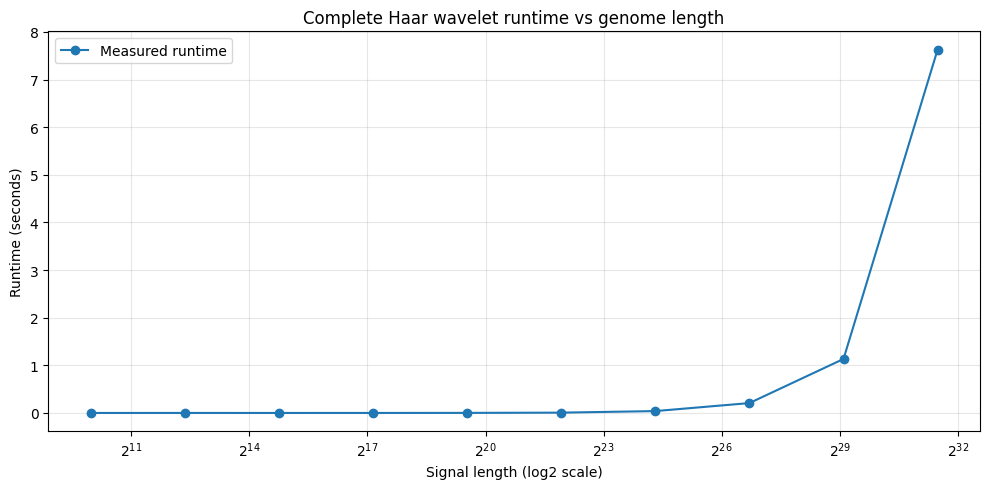

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(
    haar_runtime_df["signal_length"],
    haar_runtime_df["runtime_seconds"],
    marker="o",
    label="Measured runtime",
)
plt.xscale("log", base=2)
plt.xlabel("Signal length (log2 scale)")
plt.ylabel("Runtime (seconds)")
plt.title("Complete Haar wavelet runtime vs genome length")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
